<a href="https://colab.research.google.com/github/EJS777/school/blob/main/copy_of_pa01_training_a_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptron Algorithm 01 — Training a Perceptron (10 ⭕️pts)

**Code:** `PA01`  ·  **Type:** Colab notebook  ·  **Points:** 10


## Objective

Examine a perceptron training. This assignment is mostly example code. You will need to make very few edits to the code.

It is in your best interest to *understand how the code works* and think about the questions carefully.

## Details

Implementation of a **single-layer perceptron** like Rosenblatt's (1957–1958) from scratch.

- Train a perceptron on a **linearly separable** 2D dataset.
- Visualize the **decision boundary** and the **learning curve** (mistakes per epoch).
- Try **logical gates** AND/OR with a single-layer perceptron.
- Implement for **XOR** with a single-layer perceptron.

**Perceptron Update Rule:**
For a sample $\mathbf{x}\in\mathbb{R}^d$ with label $y\in\{-1, +1\}$, prediction $\hat{y}\in\{-1,+1\}$, and learning rate $\eta>0$:

$$ \mathbf{w} \leftarrow \mathbf{w} + \eta \,(y-\hat{y})\, \mathbf{x} $$
$$ b \leftarrow b + \eta \,(y-\hat{y}) $$

Because both $y$ and $\hat{y}$ are $\pm 1$, the factor $(y-\hat{y})$ can only ever be:

| | $y$ | $\hat{y}$ | $(y-\hat{y})$ |
|---|---|---|---|
| correct | $+1$ | $+1$ | $0$ |
| correct | $-1$ | $-1$ | $0$ |
| **mistake** | $+1$ | $-1$ | $+2$ |
| **mistake** | $-1$ | $+1$ | $-2$ |

So **nothing happens on a correct prediction**, and every mistake moves $\mathbf{w}$ by $\pm 2\eta\,\mathbf{x}$.
The update is applied **immediately, one sample at a time** (this is *online* or *stochastic* learning —
we do **not** wait until the end of an epoch and add everything up).

**Terms from lecture:**

- An **update** is one edit of $\mathbf{w}$ and $b$, caused by one misclassified sample.
- An **epoch** is one full pass over *all* the training samples. One epoch can contain many updates.


## Task 0 — Run these cells with shift+enter

Tip: If you are unfamiliar with some of the python code and you would like to learn more use the **Gemini->Explain Code** option.

Alternatively, see the bonus notebooks on Canvas. You do NOT need to complete them or turn them in. Those are just examples of basic python code.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def make_linear_separable(n_per_class=80, distance=0.6, margin=0.05, seed=7):
    """Generate two 2D Gaussian blobs that are GUARANTEED linearly separable.

    The true separating line is x1 + x2 = 0. We draw points from two Gaussians
    and *reject* any point that lands on the wrong side of that line, or inside
    a band of half-width `margin` around it. What comes back is therefore always
    separable by a single straight line -- no luck involved.

    distance : how far apart the two blob centers are. Smaller = harder.
    margin   : how close a point is allowed to get to the true line.
               Smaller = tighter squeeze = more epochs before convergence.
    """
    rng = np.random.default_rng(seed)
    w_true = np.array([1.0, 1.0]) / np.sqrt(2.0)   # unit normal of the true line
    cov = np.array([[0.7, 0.0], [0.0, 0.7]])
    blobs = []
    for sign, mean in ((+1.0, np.array([ distance,  distance])),
                       (-1.0, np.array([-distance, -distance]))):
        kept = np.empty((0, 2))
        while len(kept) < n_per_class:
            batch = rng.multivariate_normal(mean, cov, size=4 * n_per_class)
            kept = np.vstack([kept, batch[sign * (batch @ w_true) > margin]])
        blobs.append(kept[:n_per_class])
    X = np.vstack(blobs)
    y = np.hstack([np.ones(n_per_class), -np.ones(n_per_class)])
    return X, y


def plot_data_and_boundary(X, y, w, b, title="Decision Boundary"):
    """Plot 2D data and the perceptron decision boundary w.x + b = 0."""
    plt.figure()
    plt.scatter(X[y == 1, 0],  X[y == 1, 1],  label="class +1", alpha=0.7)
    plt.scatter(X[y == -1, 0], X[y == -1, 1], label="class -1", alpha=0.7)
    xs = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    if abs(w[1]) > 1e-8:                      # boundary: w0*x1 + w1*x2 + b = 0
        plt.plot(xs, -(w[0] / w[1]) * xs - b / w[1], "k-", label="boundary")
    elif abs(w[0]) > 1e-8:                    # vertical line
        plt.axvline(-b / w[0], color="k", label="boundary")
    plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.show()


def plot_learning_curve(errors, title="Mistakes per Epoch", save_as=None):
    plt.figure()
    plt.plot(range(1, len(errors) + 1), errors, marker="o")
    plt.xlabel("Epoch"); plt.ylabel("Mistakes (updates) in this epoch")
    plt.title(title); plt.grid(alpha=0.3)
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    if save_as is not None:
        plt.savefig(save_as, dpi=150, bbox_inches="tight")
        print(f"Saved {save_as} -- turn this file in.")
    plt.show()


In [ ]:
class Perceptron:
    """Rosenblatt single-layer perceptron for binary classification.

    Learns with  w <- w + lr*(y - yhat)*x  and  b <- b + lr*(y - yhat),
    applied one sample at a time (stochastic / online updates).
    """

    def __init__(self, lr=0.01, max_epochs=500, shuffle=True,
                 init="random", init_scale=3.0, seed=0):
        self.lr = lr
        self.max_epochs = max_epochs
        self.shuffle = shuffle
        self.init = init              # "random" or "zeros"
        self.init_scale = init_scale  # how far from the origin we start
        self.seed = seed              # every run with the same seed is identical
        self.w = None
        self.b = None
        self.errors_ = []             # mistakes made in each epoch
        self.n_updates_ = 0           # total mistakes across all epochs

    def _activation(self, z):
        # NOTE: z == 0 means the point sits exactly ON the boundary, which is
        # not a correct classification of anything. We send it to -1 so that a
        # point on the line always counts as a mistake for a +1 sample.
        return np.where(z > 0.0, 1.0, -1.0)

    def net_input(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return self._activation(self.net_input(X))

    def fit(self, X, y):
        rng = np.random.default_rng(self.seed)   # this instance's own RNG
        n_samples, n_features = X.shape

        if self.init == "zeros":
            self.w = np.zeros(n_features, dtype=float)
            self.b = 0.0
        else:
            self.w = rng.normal(0.0, self.init_scale, n_features)
            self.b = float(rng.normal(0.0, self.init_scale))

        self.errors_ = []
        self.n_updates_ = 0

        for epoch in range(self.max_epochs):
            # One epoch = one full pass over ALL the samples.
            order = rng.permutation(n_samples) if self.shuffle else np.arange(n_samples)

            mistakes = 0
            for i in order:
                xi, target = X[i], y[i]
                y_hat = 1.0 if (self.w @ xi + self.b) > 0.0 else -1.0
                update = self.lr * (target - y_hat)     # 0, +2*lr, or -2*lr
                if update != 0.0:
                    self.w = self.w + update * xi       # one update, applied NOW
                    self.b = self.b + update
                    mistakes += 1
                    self.n_updates_ += 1

            self.errors_.append(mistakes)
            if mistakes == 0:
                break                                   # converged
        return self

    def converged(self):
        return len(self.errors_) > 0 and self.errors_[-1] == 0

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))


## Task 1 — Train on the linearly separable dataset

Run the cell below. Look at **both** plots: the decision boundary, and the learning curve
showing how many mistakes the perceptron made in each epoch.

Weights w:         [0.86236697 0.87132111]
Bias b:            0.06126795132984486
Training accuracy: 1.0
Converged?         True
Epochs used:       3
Total updates:     93
Mistakes/epoch:    [92, 1, 0]


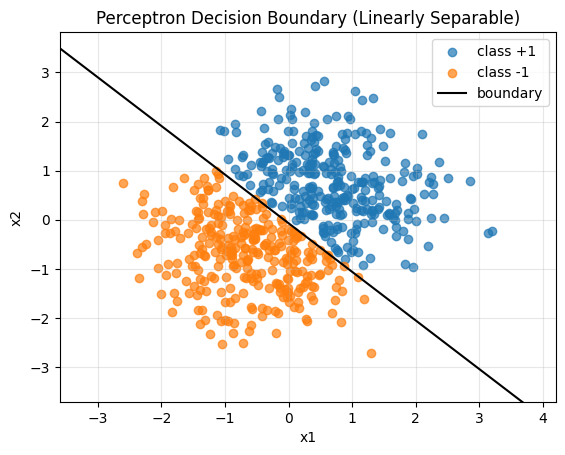

Saved pa01_learning_curve.png -- turn this file in.


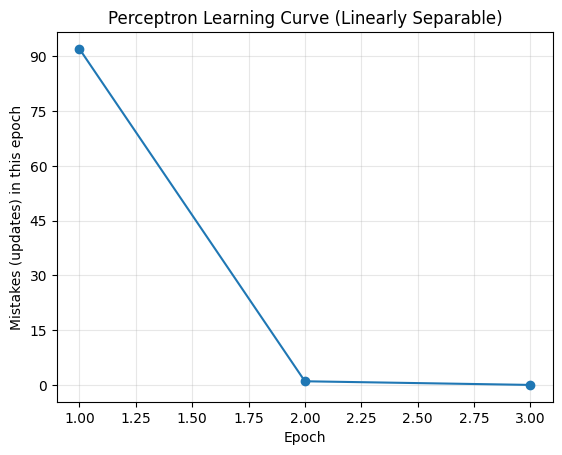

In [ ]:
# Generate a linearly separable dataset
X, y = make_linear_separable(n_per_class=300, distance=.5, margin=0.05, seed=8)

# Define the perceptron, then train it.
# lr = learning rate, max_epochs = how many full passes we allow before giving up.
p = Perceptron(lr=0.01, max_epochs=500, init_scale=3.0, seed=0)
p.fit(X, y)

print("Weights w:        ", p.w)
print("Bias b:           ", p.b)
print("Training accuracy:", p.score(X, y))
print("Converged?        ", p.converged())
print("Epochs used:      ", len(p.errors_))
print("Total updates:    ", p.n_updates_)
print("Mistakes/epoch:   ", p.errors_)

plot_data_and_boundary(X, y, p.w, p.b, title="Perceptron Decision Boundary (Linearly Separable)")
plot_learning_curve(p.errors_, title="Perceptron Learning Curve (Linearly Separable)",
                    save_as="pa01_learning_curve.png")


## Task 2 — Train the perceptron for Logical Gates (AND, OR)

Make the inputs $x\in\{0,1\}^2$ and labels $y\in\{-1,+1\}$.

Sometimes you will see this called mapping 0→-1 and 1→+1.

---

*If you want to see an example of plot style changes, see the plots I made for class [here](https://colab.research.google.com/drive/1j1qeWICD8w7DVw5t-JUMe6BOvMVvGMT_?usp=sharing)*

---

AND predictions: [-1. -1. -1.  1.]  target: [-1. -1. -1.  1.]
AND accuracy:    1.0  converged: True


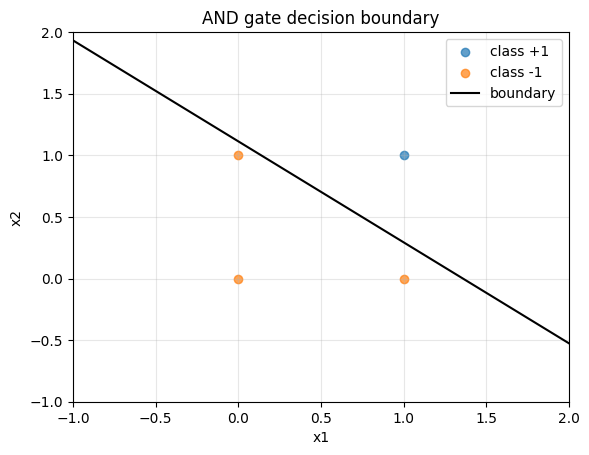

OR predictions:  [-1.  1.  1.  1.]  target: [-1.  1.  1.  1.]
OR accuracy:     1.0  converged: True


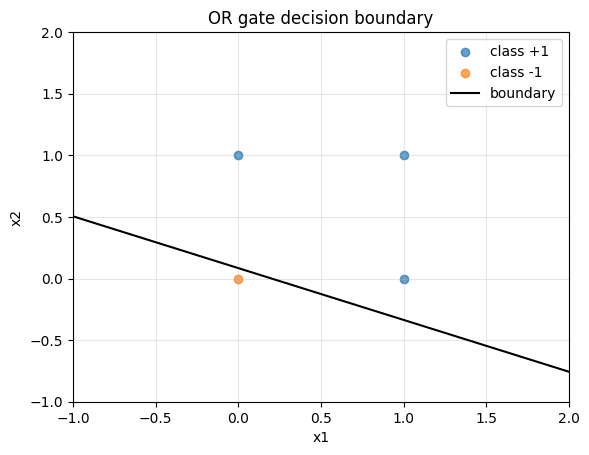

In [ ]:
def to_pm1(z):   # map 0,1 -> -1,+1
    return np.where(np.asarray(z, dtype=float) > 0, 1.0, -1.0)

X_gate = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)

# AND
y_and = to_pm1([0, 0, 0, 1])
p_and = Perceptron(lr=0.2, max_epochs=50, init_scale=1.0, seed=1).fit(X_gate, y_and)
print("AND predictions:", p_and.predict(X_gate), " target:", y_and)
print("AND accuracy:   ", p_and.score(X_gate, y_and), " converged:", p_and.converged())
plot_data_and_boundary(X_gate, y_and, p_and.w, p_and.b, title="AND gate decision boundary")

# OR
y_or = to_pm1([0, 1, 1, 1])
p_or = Perceptron(lr=0.2, max_epochs=50, init_scale=1.0, seed=1).fit(X_gate, y_or)
print("OR predictions: ", p_or.predict(X_gate), " target:", y_or)
print("OR accuracy:    ", p_or.score(X_gate, y_or), " converged:", p_or.converged())
plot_data_and_boundary(X_gate, y_or, p_or.w, p_or.b, title="OR gate decision boundary")


## Task 3 — The Learning Rate

The cell below trains the **same** perceptron on the **same** data, changing only the learning rate $\eta$.

Run it, then answer Q1.


In [ ]:
X, y = make_linear_separable(n_per_class=80, distance=0.6, margin=0.05, seed=7)

print(f"{'lr':>9} | {'epochs':>7} | {'updates':>8} | {'converged?':>11} | {'accuracy':>9}")
print("-" * 56)
for lr in [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]:
    q = Perceptron(lr=lr, max_epochs=500, init_scale=3.0, seed=0).fit(X, y)
    print(f"{lr:>9} | {len(q.errors_):>7} | {q.n_updates_:>8} | "
          f"{str(q.converged()):>11} | {q.score(X, y):>9.4f}")

# Now change something else -- the dataset -- and re-run.
# Try distance in {0.3, 0.6, 1.5} and margin in {0.01, 0.05, 0.3}.
# Remember: the data is ALWAYS separable, so the perceptron must eventually converge.


       lr |  epochs |  updates |  converged? |  accuracy
--------------------------------------------------------
   0.0001 |     500 |     8500 |       False |    0.9812
    0.001 |      79 |      901 |        True |    1.0000
     0.01 |       9 |       91 |        True |    1.0000
      0.1 |       2 |        9 |        True |    1.0000
      1.0 |       2 |        7 |        True |    1.0000
     10.0 |       2 |        8 |        True |    1.0000


### ⭕️⭕️⭕️ Q1: What did you notice when you changed the learning rate?

Address all three:

1. Which learning rates converged, and which did not within `max_epochs`?
2. Describe the *trend* in the number of epochs as $\eta$ grows. Does it keep improving forever, or does it flatten out?
3. The perceptron starts from a random $\mathbf{w}_0, b_0$ that is *far* from a good answer.
   Using the update rule $\mathbf{w} \leftarrow \mathbf{w} + \eta(y-\hat{y})\mathbf{x}$, explain why a **very small**
   $\eta$ struggles. (Hint: how big is one step compared to how far $\mathbf{w}_0$ is from where it needs to be?)



1.) Every learning rate converged except for the very lowest .0001.

2.) As eta grows the number of epochs and updates decreases.  It seems to flatten out at the higher learning rates where 0.1 - 10.0 all finish in 2 epochs and only make very small decreases in update counts (dropping from 9 to 7).  
3.) A very small eta is inefficient because the recalculated boundary is often still on the same incorrect side of the point it just evaluated.  Instead of jumping enough that it makes the y hat prediction correct, it’s so small that the prediction is often still wrong.  


## Task 4 — Try XOR with a Single-Layer Perceptron

XOR predictions: [-1. -1. -1. -1.]  target: [-1.  1.  1. -1.]
XOR accuracy:    0.5  converged: False
Mistakes/epoch:  [3, 1, 3, 4, 1, 3, 4, 3, 3, 2, 2, 3, 4, 1, 4, 3, 4, 3, 2, 1, 3, 2, 2, 4, 3, 4, 3, 3, 4, 3, 4, 3, 3, 3, 2, 2, 3, 3, 3, 2, 3, 3, 1, 3, 3, 3, 2, 3, 3, 4]


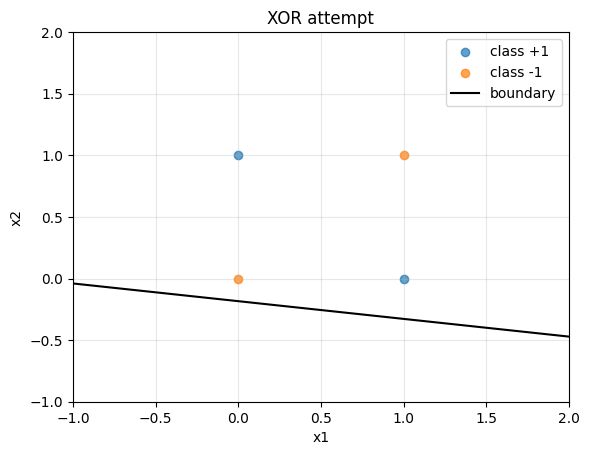

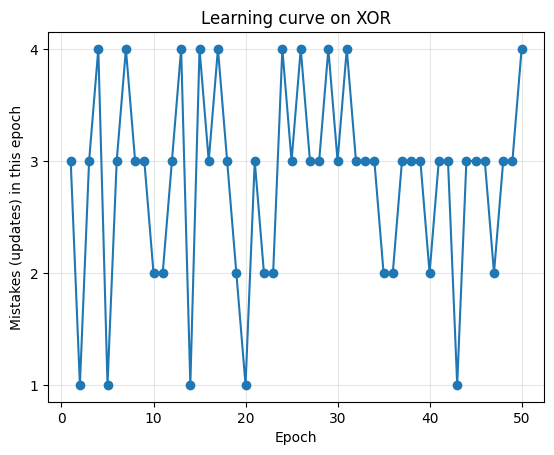

In [ ]:
# XOR dataset
y_xor = to_pm1([0, 1, 1, 0])
p_xor = Perceptron(lr=0.2, max_epochs=50, init_scale=1.0, seed=1).fit(X_gate, y_xor)
print("XOR predictions:", p_xor.predict(X_gate), " target:", y_xor)
print("XOR accuracy:   ", p_xor.score(X_gate, y_xor), " converged:", p_xor.converged())
print("Mistakes/epoch: ", p_xor.errors_)
plot_data_and_boundary(X_gate, y_xor, p_xor.w, p_xor.b, title="XOR attempt")
plot_learning_curve(p_xor.errors_, title="Learning curve on XOR")


### Assignment Questions
---


### ⭕️⭕️⭕️ Q2: What happened when you tried the XOR?



The XOR did not converge and the program maxed out on its epoch limit.  

### ⭕️⭕️⭕️ Q3: Why do you think that happened?



The XOR never converged and it never will because XOR is a non-linearly Separable function.  There is no way to draw a straight boundary separating the 0s and 1s.  **< your answer here >**

### Turning it in

Upload to Canvas:

1. A **link** to your completed copy of this notebook
2. A **PDF** of the completed notebook with all plots and printed output visible (see instructions on Canvas)
3. The **`pa01_learning_curve.png`** file saved by Task 1

Make sure your answers to **Q1, Q2 and Q3** are filled in before you export.

# Check out the bonus section once you are done answering.

## Perceptron with scikit-learn

OK, tbh, no one would code a perceptron from scratch nowadays...

Instead, one would use the perceptron model in scikit-learn. See the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)

I suggest running it (there is a non-zero probability that it will show up in a future assignment). Actually, see extra credit below.

## Extra credit:

- Make synthetic data for two separable blobs of data as we did above. You may use `make_linear_separable`, or make your own blobs as long as one can draw a line to separate them.
- Use the scikit-learn perceptron model to find a boundary line and print the `w` and `b` that result.
- Plot the scikit-learn boundary.

- Run your perceptron.
- Plot your perceptron boundary.


EXTRA

⭕️⭕️

scikit-learn  w = [2.00192959 2.5902916 ]   b = 0.0
scikit-learn  training accuracy = 1.0


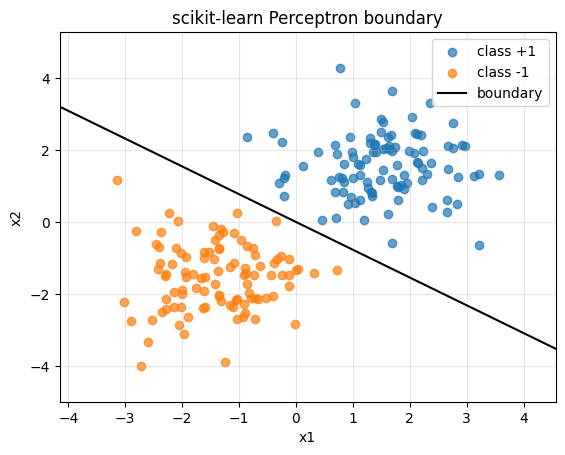


yours         w = [1.05531801 1.01303765]   b = 0.3412679513298449
yours         training accuracy = 1.0


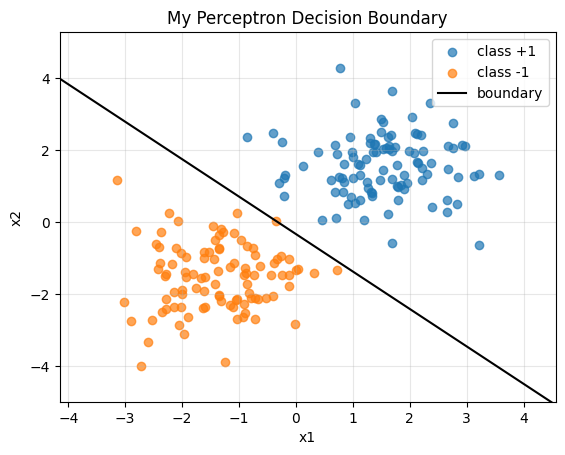

In [ ]:
from sklearn.linear_model import Perceptron as SKPerceptron

# 1. Make separable data (or build your own).
X_ec, y_ec = make_linear_separable(n_per_class=100, distance=1.5, margin=0.05, seed=3)

# 2. Fit scikit-learn's perceptron.
#    tol=None turns off early stopping so it runs until it stops making mistakes.
clf = SKPerceptron(max_iter=1000, tol=None, random_state=0).fit(X_ec, y_ec)

w_sk = clf.coef_[0]
b_sk = float(clf.intercept_[0])
print("scikit-learn  w =", w_sk, "  b =", b_sk)
print("scikit-learn  training accuracy =", clf.score(X_ec, y_ec))

# 3. Plot it with the same helper we used above.
plot_data_and_boundary(X_ec, y_ec, w_sk, b_sk, title="scikit-learn Perceptron boundary")


# 4. Compare against your own implementation on the SAME data.
p_mine = Perceptron(lr=0.01, max_epochs=500, init_scale=3.0, seed=0)
p_mine.fit(X_ec, y_ec)

print("\nyours         w =", p_mine.w, "  b =", p_mine.b)
print("yours         training accuracy =", p_mine.score(X_ec, y_ec))

# Your perceptron plot
plot_data_and_boundary(X_ec, y_ec, p_mine.w, p_mine.b, title="My Perceptron Decision Boundary")
#plot_learning_curve(p_mine.errors_, title="My Perceptron Learning Curve")